## Practice for Using PySpark and Python

For this practice, you'll be using a dataset from a Taiwanese financial company, and the task is to determine which individuals are going to default on their credit cards based on characteristics such as limit balance, past payment history, age, marriage status, and sex.

This practice is a structured data exploration process, covering:

- **Initial Data Exploration:** Understanding data structure, displaying records, and identifying non-numeric features.
- **Data Visualization:** Using bar plots to evaluate categorical variables and identify distribution patterns.
- **Data Binning:** Consolidating rarely occurring values to improve model readiness.
- **Target Variable Analysis:** Examining class balance and segmenting data to identify patterns by demographics.

Each step is relevant to building familiarity with data and preparing for machine learning tasks. See our problem-solving process outline for additional context.

The objective here is to develop skills in handling financial datasets, using PySpark tools to manage large datasets, and drawing insights from initial exploratory steps. This practice will also strengthen your ability to identify trends and imbalances, essential for predictive modeling tasks. By the end, you'll be able to approach a dataset systematically, refining your skills in data wrangling and visualization.

### Instructions

### Part 1: Initial Data Exploration

#### Step 1: Import and Initialize

Get started by writing the relevant import statement and creating a local SparkSession called "spark," then use that SparkSession to read "credit_card_default.csv" into a Spark SQL DataFrame.

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.master("local").getOrCreate()

spark_df = spark.read.csv("credit_card_default.csv", header = True, inferSchema = True)

#### Step 2: Display and Print

Use `.head()` to display the first five records, and print out the schema.

In [2]:
spark_df.head(5)

[Row(ID=2, LIMIT_BAL=120000.0, SEX='Female', EDUCATION='College', MARRIAGE='Single', AGE=26, PAY_0=-1, PAY_2=2, PAY_3=0, PAY_4=0, PAY_5=0, PAY_6=2, BILL_AMT1=2682.0, BILL_AMT2=1725.0, BILL_AMT3=2682.0, BILL_AMT4=3272.0, BILL_AMT5=3455.0, BILL_AMT6=3261.0, PAY_AMT1=0.0, PAY_AMT2=1000.0, PAY_AMT3=1000.0, PAY_AMT4=1000.0, PAY_AMT5=0.0, PAY_AMT6=2000.0, default=1),
 Row(ID=3, LIMIT_BAL=90000.0, SEX='Female', EDUCATION='College', MARRIAGE='Single', AGE=34, PAY_0=0, PAY_2=0, PAY_3=0, PAY_4=0, PAY_5=0, PAY_6=0, BILL_AMT1=29239.0, BILL_AMT2=14027.0, BILL_AMT3=13559.0, BILL_AMT4=14331.0, BILL_AMT5=14948.0, BILL_AMT6=15549.0, PAY_AMT1=1518.0, PAY_AMT2=1500.0, PAY_AMT3=1000.0, PAY_AMT4=1000.0, PAY_AMT5=1000.0, PAY_AMT6=5000.0, default=0),
 Row(ID=4, LIMIT_BAL=50000.0, SEX='Female', EDUCATION='College', MARRIAGE='Married', AGE=37, PAY_0=0, PAY_2=0, PAY_3=0, PAY_4=0, PAY_5=0, PAY_6=0, BILL_AMT1=46990.0, BILL_AMT2=48233.0, BILL_AMT3=49291.0, BILL_AMT4=28314.0, BILL_AMT5=28959.0, BILL_AMT6=29547.0, P

In [3]:
spark_df.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- LIMIT_BAL: double (nullable = true)
 |-- SEX: string (nullable = true)
 |-- EDUCATION: string (nullable = true)
 |-- MARRIAGE: string (nullable = true)
 |-- AGE: integer (nullable = true)
 |-- PAY_0: integer (nullable = true)
 |-- PAY_2: integer (nullable = true)
 |-- PAY_3: integer (nullable = true)
 |-- PAY_4: integer (nullable = true)
 |-- PAY_5: integer (nullable = true)
 |-- PAY_6: integer (nullable = true)
 |-- BILL_AMT1: double (nullable = true)
 |-- BILL_AMT2: double (nullable = true)
 |-- BILL_AMT3: double (nullable = true)
 |-- BILL_AMT4: double (nullable = true)
 |-- BILL_AMT5: double (nullable = true)
 |-- BILL_AMT6: double (nullable = true)
 |-- PAY_AMT1: double (nullable = true)
 |-- PAY_AMT2: double (nullable = true)
 |-- PAY_AMT3: double (nullable = true)
 |-- PAY_AMT4: double (nullable = true)
 |-- PAY_AMT5: double (nullable = true)
 |-- PAY_AMT6: double (nullable = true)
 |-- default: integer (nullable = true)



#### Step 3: Select and Show All Distinct Categories

We have three non-numeric features. For each non-numeric (string) feature, select and show all distinct categories.

In [4]:
#Select and show each distinct category in the SEX column:
spark_df.select("SEX").distinct().show()

#Select and show each distinct category in the EDUCATION column:
spark_df.select("EDUCATION").distinct().show()

#Select and show each distinct category in the MARRIAGE column:
spark_df.select("MARRIAGE").distinct().show()

+------+
|   SEX|
+------+
|Female|
|  Male|
+------+

+-----------+
|  EDUCATION|
+-----------+
|High School|
|          0|
|          5|
|          6|
|      Other|
|   Graduate|
|    College|
+-----------+

+--------+
|MARRIAGE|
+--------+
|       0|
|   Other|
| Married|
|  Single|
+--------+



We have some extraneous values in our categories. For example, both EDUCATION and MARRIAGE have a category 0.

Let's create some visualizations of each of these to determine just how many of them there are.

#### Step 4: Bar Plots of EDUCATION and MARRIAGE

Create bar plots of the variables EDUCATION and MARRIAGE to see how the records are distributed between the categories.

- To create a bar plot, you need to group by the category using `.groupBy()` and then aggregate by the count in that category using `.count()`. That will result in a small DataFrame containing EDUCATION and count columns.
- Then the easiest way to create a bar plot is to call `.toPandas()` to make that small Spark SQL DataFrame into a Pandas DataFrame, and call `.plot()` on the Pandas DataFrame.

+-----------+-----+
|  EDUCATION|count|
+-----------+-----+
|High School| 4917|
|          0|   14|
|          5|  280|
|          6|   51|
|      Other|  123|
|   Graduate|10585|
|    College|14029|
+-----------+-----+



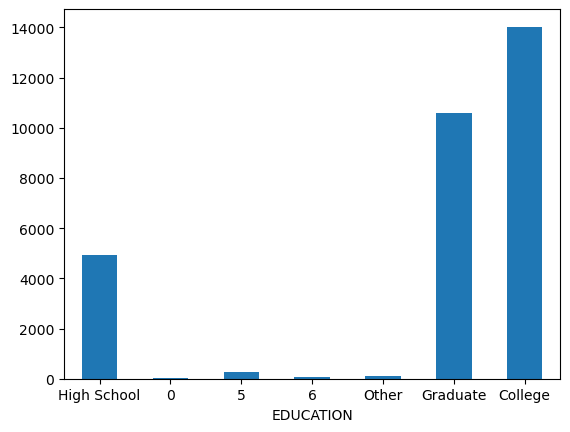

In [5]:
#Create a bar plot of the counts in each category of the EDUCATION column:
#Create a small df containing the counts in each category:
education_category_counts = spark_df.groupBy("EDUCATION").count()
education_category_counts.show()

#Create a bar plot to show the relative sizes of each category:
education_category_counts.toPandas().plot(kind = "bar", x = "EDUCATION", y = "count", rot = 0, legend = False);

+--------+-----+
|MARRIAGE|count|
+--------+-----+
|       0|   54|
|   Other|  323|
| Married|13658|
|  Single|15964|
+--------+-----+



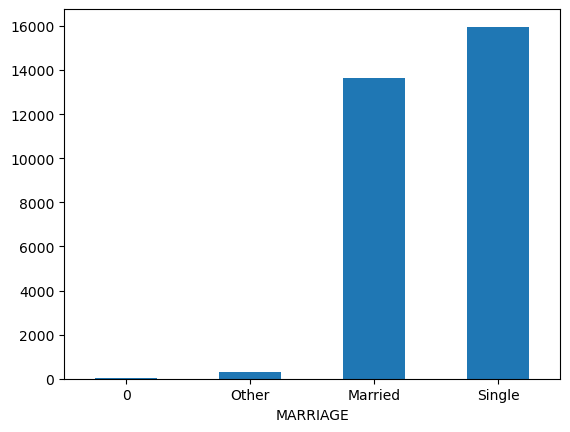

In [6]:
#Create a bar plot of the counts in each category of the MARRIAGE column:
#Create a small df containing the counts in each category:
marriage_category_counts = spark_df.groupBy("MARRIAGE").count()
marriage_category_counts.show()

#Create a bar plot to show the relative sizes of each category:
marriage_category_counts.toPandas().plot(kind = "bar", x = "MARRIAGE", y = "count", rot = 0, legend = False);

### Part 2: Binning

The approach we'll use is similar to the CASE WHEN technique in SQL. If this were a SQL query, it would look something like this:

```
SELECT CASE
            WHEN EDUCATION = '0' THEN 'Other'
            WHEN EDUCATION = '5' THEN 'Other'
            WHEN EDUCATION = '6' THEN 'Other'
            ELSE EDUCATION
            END AS EDUCATION
  FROM credit_card_default;
```

With Spark SQL DataFrames, this is achieved using `.withColumn()` in conjunction with `.when()` and `.otherwise()`.

#### Step 5: Bin EDUCATION and MARRIAGE

There are barely any records in the 0, 5, and 6 categories. Let's go ahead and bin (combine) those with the current Other records into a single catch-all Other category for both EDUCATION and MARRIAGE.

In [7]:
from pyspark.sql.functions import when

#Bin EDUCATION categories together:
df_with_education_binned = spark_df.withColumn("EDUCATION",
                                               when(spark_df["EDUCATION"].isin([0, 5, 6]), "Other")
                                               .otherwise(spark_df["EDUCATION"]))

#Bin MARRIAGE categories together:
df_with_all_binned = df_with_education_binned.withColumn("MARRIAGE",
                                                         when(df_with_education_binned["MARRIAGE"] == 0, "Other")
                                                         .otherwise(df_with_education_binned["MARRIAGE"]))

#Let's select and show all the distinct categories in both the EDUCATION and MARRIAGE columns again. The 0, 5, and
#6 categories should be subsumed under "Other" now:
df_with_all_binned.select("EDUCATION").distinct().show()
df_with_all_binned.select("MARRIAGE").distinct().show()

+-----------+
|  EDUCATION|
+-----------+
|High School|
|      Other|
|   Graduate|
|    College|
+-----------+

+--------+
|MARRIAGE|
+--------+
|   Other|
| Married|
|  Single|
+--------+



#### Step 6: Plot the Bins

Let's also re-create the plots from earlier, now that the data has been binned:

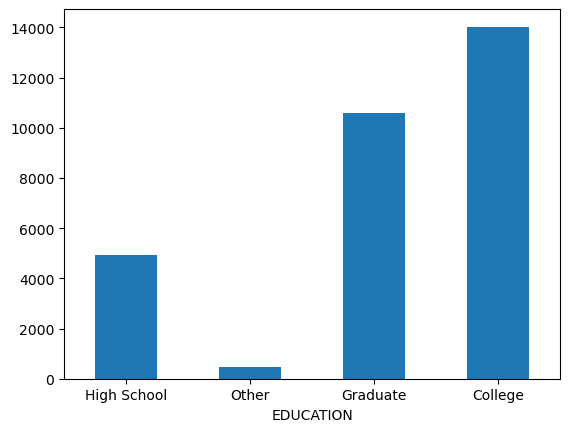

In [8]:
#Create a bar plot of the counts in each category of the new EDUCATION column:
df_with_all_binned.groupBy("EDUCATION").count().toPandas().plot(kind = "bar", x = "EDUCATION", y = "count", rot = 0, legend = False);

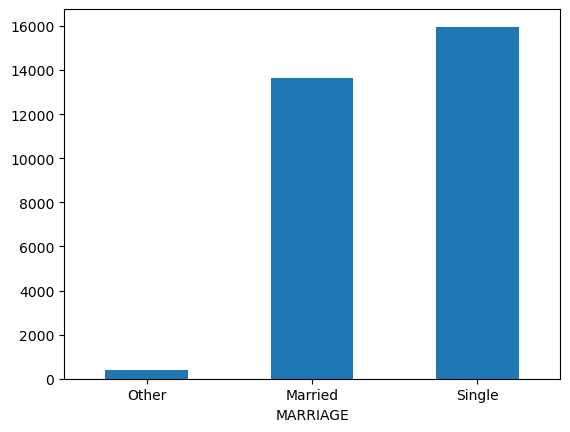

In [9]:
#Create a bar plot of the counts in each category of the new MARRIAGE column:
df_with_all_binned.groupBy("MARRIAGE").count().toPandas().plot(kind = "bar", x = "MARRIAGE", y = "count", rot = 0, legend = False);

Much better. Let's do a little more investigation into our target variable before diving into the machine learning aspect of this project.

### Part 3: Class Balance Exploration

First, let's look at the overall distribution of class balance of the "default" column (the target for our upcoming machine learning process).

#### Step 7: Bar Charts for (Non-)Defaults

Create a bar plot to compare the number of defaults (1) vs. non-defaults (0). Consider customizing your plot labels as well, since 0 and 1 are not particularly understandable values.

+-------+-----+
|default|count|
+-------+-----+
|      0|23364|
|      1| 6635|
+-------+-----+



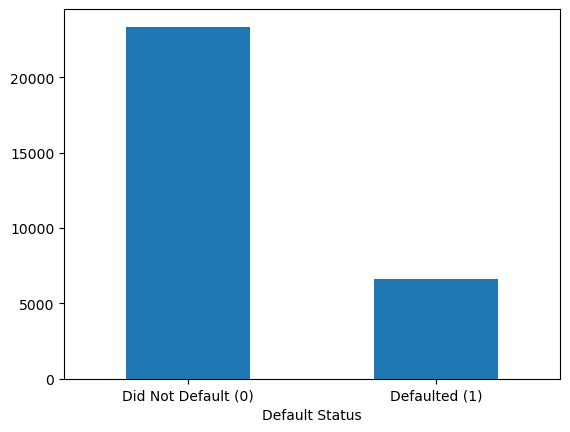

In [10]:
#Create a small df containing the counts of those who defaulted (1) or did not default (0):
default_counts = df_with_all_binned.groupBy("default").count().orderBy("default")
default_counts.show()

#Create a bar plot to compare the number of defaults (1) with the number of non-defaults (0):
#Import Matplotlib to help customize our graph:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
default_counts.toPandas().plot(kind = "bar", x = "default", y = "count", rot = 0, legend = False, ax = ax)
ax.set_xlabel("Default Status")
ax.set_xticklabels(["Did Not Default (0)", "Defaulted (1)"])
plt.show()

We have a fairly imbalanced dataset.

#### Step 8: Group by "default" and SEX

Let's also visualize the difference in default rate between males and females in this dataset. Group by both "default" and SEX and visualize the comparison.

+-------+------+-----+
|default|   SEX|count|
+-------+------+-----+
|      0|Female|14349|
|      0|  Male| 9015|
|      1|Female| 3762|
|      1|  Male| 2873|
+-------+------+-----+



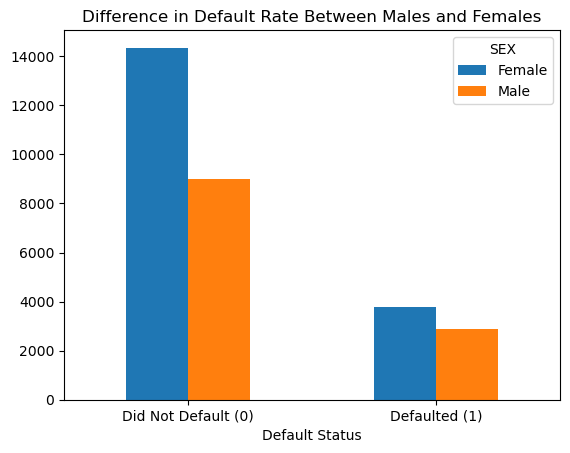

In [11]:
#Create a small df containing the counts of those who defaulted (1) or did not default (0), grouped by SEX:
default_counts_by_sex = df_with_all_binned.groupBy(["default", "SEX"]).count().orderBy(["default", "SEX"])
default_counts_by_sex.show()

#Create a bar plot to compare the number of defaults (1) with the number of non-defaults (0), grouped by SEX:
fig, ax = plt.subplots()
default_counts_by_sex.toPandas().pivot(index = "default", columns = "SEX", values = "count").plot(kind = "bar", rot = 0, ax = ax)
ax.set_xlabel("Default Status")
ax.set_xticklabels(["Did Not Default (0)", "Defaulted (1)"])
ax.set_title("Difference in Default Rate Between Males and Females")
plt.show()

Males have an ever-so-slightly higher default rate than females, and also represent a smaller proportion of the dataset.

#### Step 9: Stop the SparkContext

In [12]:
spark.stop()